In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/flo_processed.csv', parse_dates=[
    'first_order_date', 'last_order_date',
    'last_order_date_online', 'last_order_date_offline'
])

ANALYSIS_DATE = pd.Timestamp('2021-06-01')

print(f"Shape: {df.shape}")
df.head(3)

Shape: (19945, 24)


,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,avg_order_value,online_ratio,customer_lifetime_days,cat_kadin,cat_erkek,cat_cocuk,cat_aktifspor,cat_aktifcocuk,cat_indirim,num_categories
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,187.874000,0.800000,214,1,0,0,0,0,0,1
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,...,95.883333,0.904762,1574,1,1,1,1,0,0,4
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,117.064000,0.600000,552,1,1,0,0,0,0,2


In [2]:
# ── RFM Calculation ───────────────────────────────────────

rfm = pd.DataFrame()
rfm['customer_id'] = df['master_id']

# Recency: days since last purchase (lower = better)
rfm['recency'] = (ANALYSIS_DATE - df['last_order_date']).dt.days

# Frequency: total number of orders
rfm['frequency'] = df['total_order']

# Monetary: total spend
rfm['monetary'] = df['total_price']

print(rfm.describe())
rfm.head()

            recency     frequency      monetary
count  19945.000000  19945.000000  19945.000000
mean     134.458360      4.874605    723.153853
std      103.281149      3.563218    588.868220
min        2.000000      2.000000     59.980000
25%       43.000000      3.000000    339.980000
50%      111.000000      4.000000    545.410000
75%      202.000000      6.000000    897.780000
max      367.000000     27.000000   4363.757200


,customer_id,recency,frequency,monetary
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,5.0,939.37
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,21.0,2013.55
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,5.0,585.32
3,1854e56c-491f-11eb-806e-000d3a38a36f,135,2.0,121.97
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,86,2.0,209.98


In [ ]:
# ── RFM Scoring (1-5) ─────────────────────────────────────
# Each metric scored 1 to 5 using quintiles
# Recency: LOWER is better → reversed scoring
# Frequency & Monetary: HIGHER is better -> normal scoring

rfm['recency_score'] = pd.qcut(rfm['recency'], q=5, 
                                labels=[5, 4, 3, 2, 1])

rfm['frequency_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                                  q=5, labels=[1, 2, 3, 4, 5])

rfm['monetary_score'] = pd.qcut(rfm['monetary'], q=5, 
                                 labels=[1, 2, 3, 4, 5])

# Combine R and F into RF score (string)
rfm['RF_score'] = (rfm['recency_score'].astype(str) + 
                   rfm['frequency_score'].astype(str))

print(rfm[['recency_score','frequency_score','monetary_score','RF_score']].head(10))

  recency_score frequency_score monetary_score RF_score
0             3               4              4       34
1             3               5              5       35
2             2               4              3       24
3             3               1              1       31
4             3               1              1       31
5             4               2              1       42
6             2               3              2       23
7             1               1              1       11
8             3               4              5       34
9             1               1              1       11


In [4]:
# ── RFM Segmentation Map ──────────────────────────────────

seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5':     'Cannot Lose Them',
    r'3[1-2]':     'About to Sleep',
    r'33':         'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41':         'Promising',
    r'51':         'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]':     'Champions',
}

rfm['segment'] = rfm['RF_score'].replace(seg_map, regex=True)

print("Segment distribution:")
print(rfm['segment'].value_counts())
print()
print(f"Total customers: {len(rfm):,}")

Segment distribution:
segment
Hibernating            3604
Loyal Customers        3361
At Risk                3131
Potential Loyalists    2938
Champions              1932
About to Sleep         1629
Cannot Lose Them       1200
Need Attention          823
New Customers           680
Promising               647
Name: count, dtype: int64

Total customers: 19,945


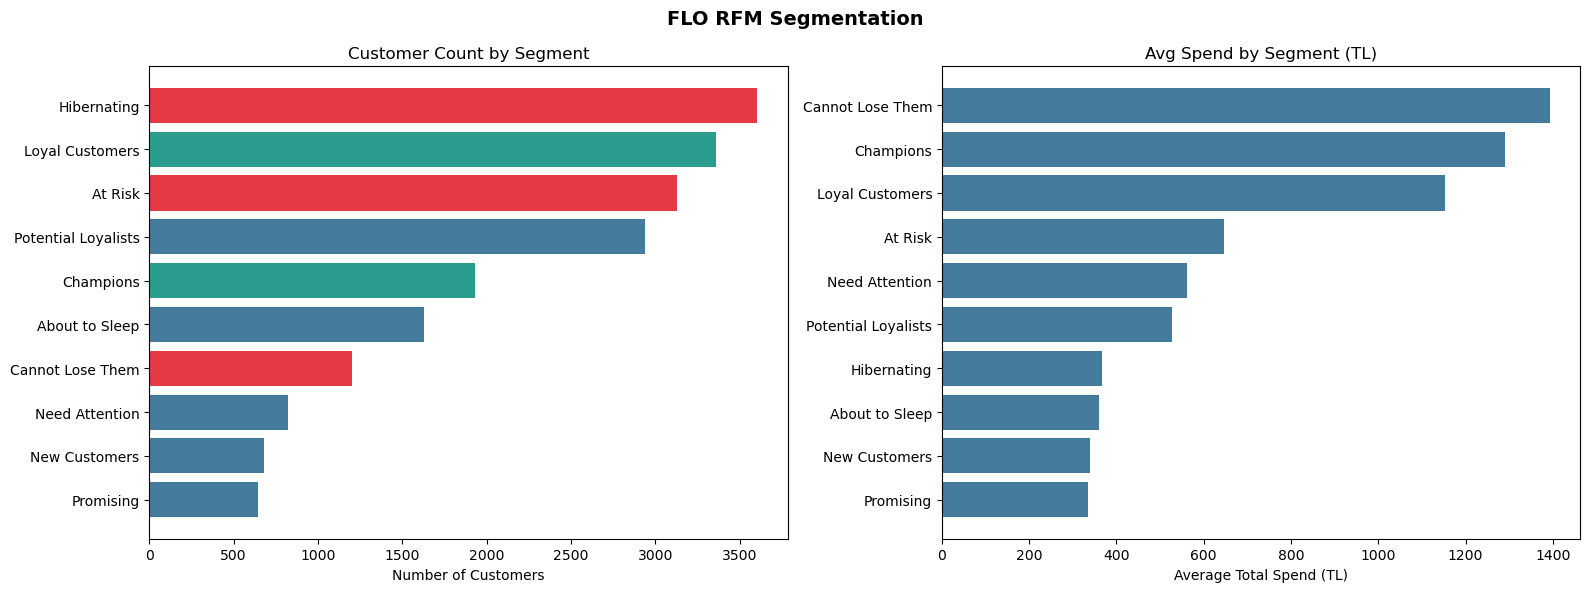

Saved!


In [7]:
# ── Segment Visualization ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FLO RFM Segmentation', fontsize=14, fontweight='bold')

# Plot 1: Customer count per segment
segment_counts = rfm['segment'].value_counts().sort_values()
colors = ['#E63946' if x in ['Hibernating', 'At Risk', 'Cannot Lose Them'] 
          else '#2A9D8F' if x in ['Champions', 'Loyal Customers']
          else '#457B9D' for x in segment_counts.index]

axes[0].barh(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Number of Customers')

# Plot 2: Average monetary value per segment
segment_monetary = rfm.groupby('segment')['monetary'].mean().sort_values()
axes[1].barh(segment_monetary.index, segment_monetary.values, color='#457B9D')
axes[1].set_title('Avg Spend by Segment (TL)')
axes[1].set_xlabel('Average Total Spend (TL)')

plt.tight_layout()
plt.savefig('../outputs/week2_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [8]:
# Save RFM table for next weeks
rfm.to_csv('../data/flo_rfm.csv', index=False)
print(f"Saved! Shape: {rfm.shape}")
print(rfm[['customer_id', 'recency', 'frequency', 
           'monetary', 'RF_score', 'segment']].head())
           

Saved! Shape: (19945, 9)
                            customer_id  recency  frequency  monetary  \
0  cc294636-19f0-11eb-8d74-000d3a38a36f       95        5.0    939.37   
1  f431bd5a-ab7b-11e9-a2fc-000d3a38a36f      105       21.0   2013.55   
2  69b69676-1a40-11ea-941b-000d3a38a36f      186        5.0    585.32   
3  1854e56c-491f-11eb-806e-000d3a38a36f      135        2.0    121.97   
4  d6ea1074-f1f5-11e9-9346-000d3a38a36f       86        2.0    209.98   

  RF_score          segment  
0       34  Loyal Customers  
1       35  Loyal Customers  
2       24          At Risk  
3       31   About to Sleep  
4       31   About to Sleep  


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm = pd.read_csv('../data/flo_rfm.csv')
print(rfm.shape)
rfm.head()

(19945, 9)


,customer_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RF_score,segment
0,cc294636-19f0-11eb-8d74-000d3a38a36f,95,5.0,939.37,3,4,4,34,Loyal Customers
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,105,21.0,2013.55,3,5,5,35,Loyal Customers
2,69b69676-1a40-11ea-941b-000d3a38a36f,186,5.0,585.32,2,4,3,24,At Risk
3,1854e56c-491f-11eb-806e-000d3a38a36f,135,2.0,121.97,3,1,1,31,About to Sleep
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,86,2.0,209.98,3,1,1,31,About to Sleep


In [10]:
# ── Feature Selection & Scaling ───────────────────────────

# Use only R, F, M for clustering
X = rfm[['recency', 'frequency', 'monetary']].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, 
                         columns=['recency_scaled', 
                                  'frequency_scaled', 
                                  'monetary_scaled'])

print("Before scaling:")
print(X.describe().T[['mean', 'std', 'min', 'max']])
print()
print("After scaling:")
print(X_scaled.describe().T[['mean', 'std', 'min', 'max']])

Before scaling:
                 mean         std    min        max
recency    134.458360  103.281149   2.00   367.0000
frequency    4.874605    3.563218   2.00    27.0000
monetary   723.153853  588.868220  59.98  4363.7572

After scaling:
                          mean       std       min       max
recency_scaled    9.262528e-18  1.000025 -1.282535  2.251596
frequency_scaled -3.990012e-17  1.000025 -0.806764  6.209542
monetary_scaled   2.208757e-17  1.000025 -1.126212  6.182529


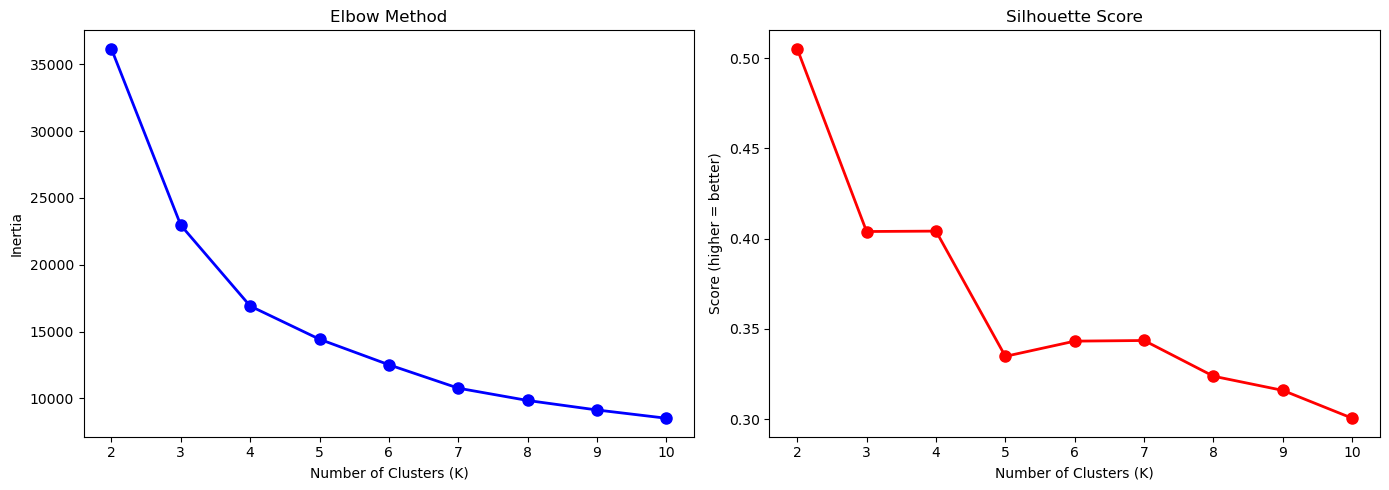

K=2  Silhouette=0.5052
K=3  Silhouette=0.4039
K=4  Silhouette=0.4042
K=5  Silhouette=0.3348
K=6  Silhouette=0.3432
K=7  Silhouette=0.3435
K=8  Silhouette=0.3237
K=9  Silhouette=0.3159
K=10  Silhouette=0.3004


In [11]:
# ── Optimal K: Elbow + Silhouette ─────────────────────────

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(K_range)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score (higher = better)')
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig('../outputs/week2_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f"K={k}  Silhouette={s:.4f}")

In [12]:
# ── Final K-Means Model (K=4) ─────────────────────────────

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Cluster profiles
cluster_profile = rfm.groupby('kmeans_cluster').agg(
    num_customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1)

cluster_profile['pct_customers'] = (
    cluster_profile['num_customers'] / len(rfm) * 100
).round(1)

print(cluster_profile)

                num_customers  avg_recency  avg_frequency  avg_monetary  \
kmeans_cluster                                                            
0                        3845         90.7            7.9        1240.0   
1                        6147        260.4            3.6         497.2   
2                        9071         71.6            3.4         471.1   
3                         882         94.0           16.6        2637.4   

                pct_customers  
kmeans_cluster                 
0                        19.3  
1                        30.8  
2                        45.5  
3                         4.4  


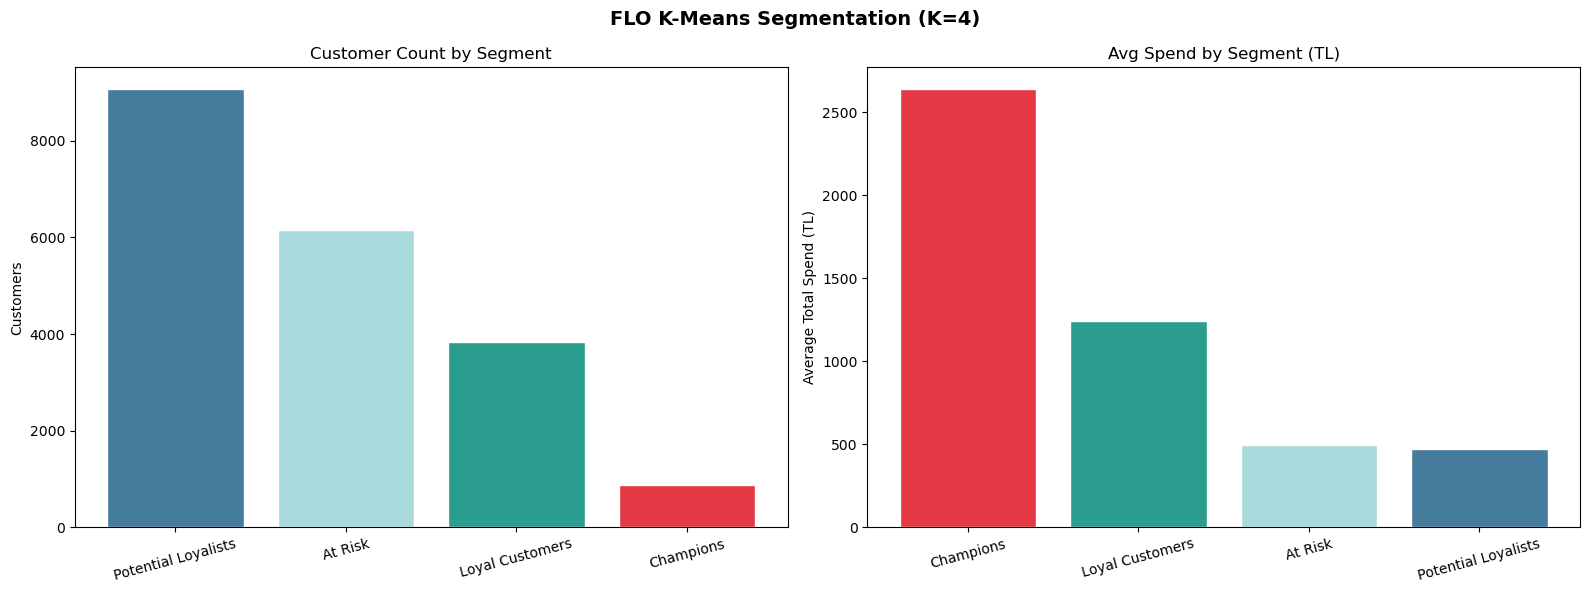

Saved!
kmeans_segment
Potential Loyalists    9071
At Risk                6147
Loyal Customers        3845
Champions               882
Name: count, dtype: int64


In [13]:
# ── Cluster Labels ────────────────────────────────────────

cluster_labels = {
    3: 'Champions',
    0: 'Loyal Customers',
    2: 'Potential Loyalists',
    1: 'At Risk'
}

rfm['kmeans_segment'] = rfm['kmeans_cluster'].map(cluster_labels)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FLO K-Means Segmentation (K=4)', 
             fontsize=14, fontweight='bold')

COLORS = {'Champions': '#E63946', 
          'Loyal Customers': '#2A9D8F',
          'Potential Loyalists': '#457B9D', 
          'At Risk': '#A8DADC'}

# Plot 1: Customer count
seg_counts = rfm['kmeans_segment'].value_counts()
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[COLORS[x] for x in seg_counts.index],
            edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Avg monetary by segment
seg_monetary = rfm.groupby('kmeans_segment')['monetary'].mean().sort_values(ascending=False)
axes[1].bar(seg_monetary.index, seg_monetary.values,
            color=[COLORS[x] for x in seg_monetary.index],
            edgecolor='white')
axes[1].set_title('Avg Spend by Segment (TL)')
axes[1].set_ylabel('Average Total Spend (TL)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/week2_kmeans_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# Save
rfm.to_csv('../data/flo_rfm.csv', index=False)
print("Saved!")
print(rfm['kmeans_segment'].value_counts())

In [14]:
# ── Segment Comparison: RFM vs K-Means ───────────────────

master = pd.read_csv('../data/flo_master.csv')

# Cross-tabulation: RFM segment vs K-Means segment
cross = pd.crosstab(
    master['segment'], 
    master['kmeans_segment'],
    margins=True
)

print("RFM vs K-Means Cross-Tabulation:")
print(cross)

RFM vs K-Means Cross-Tabulation:
kmeans_segment       At Risk  Champions  Loyal Customers  Potential Loyalists  \
segment                                                                         
About to Sleep             0          0                4                 1625   
At Risk                 2614          1              225                  291   
Cannot Lose Them         355        214              626                    5   
Champions                  0        299             1005                  628   
Hibernating             3178          0               10                  416   
Loyal Customers            0        367             1860                 1134   
Need Attention             0          0               35                  788   
New Customers              0          0                1                  679   
Potential Loyalists        0          1               78                 2859   
Promising                  0          0                1                  64

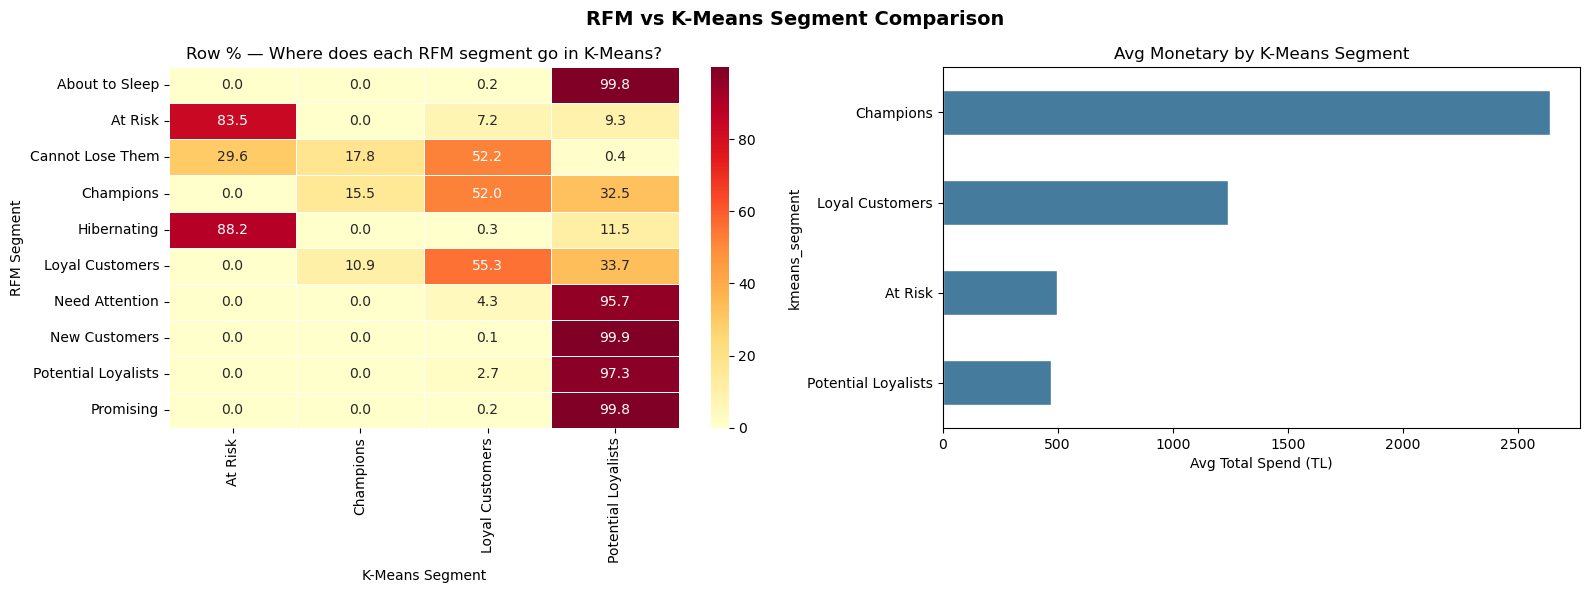

Saved!


In [15]:
# ── Overlap Visualization ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM vs K-Means Segment Comparison', 
             fontsize=14, fontweight='bold')

# Plot 1: Heatmap
cross_pct = pd.crosstab(
    master['segment'],
    master['kmeans_segment'],
    normalize='index'
).mul(100).round(1)

sns.heatmap(cross_pct, annot=True, fmt='.1f', 
            cmap='YlOrRd', ax=axes[0],
            linewidths=0.5)
axes[0].set_title('Row % — Where does each RFM segment go in K-Means?')
axes[0].set_xlabel('K-Means Segment')
axes[0].set_ylabel('RFM Segment')

# Plot 2: Avg monetary comparison
seg_compare = master.groupby('kmeans_segment').agg(
    avg_monetary=('monetary', 'mean'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean')
).round(1)

seg_compare['avg_monetary'].sort_values().plot(
    kind='barh', ax=axes[1], color='#457B9D', edgecolor='white'
)
axes[1].set_title('Avg Monetary by K-Means Segment')
axes[1].set_xlabel('Avg Total Spend (TL)')

plt.tight_layout()
plt.savefig('../outputs/week2_segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")